In [5]:
!py -m pip install pandas numpy scikit-learn matplotlib seaborn xgboost lightgbm imbalanced-learn joblib -q

In [8]:
# ── Standard libraries ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import json
import os
import warnings
warnings.filterwarnings('ignore')

# ── Visualization ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Scikit-learn: Preprocessing ─────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# ── Imbalanced learning ──────────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE

# ── Persistence ─────────────────────────────────────────────────────────────
import joblib

# ── Plot styling ─────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120


In [11]:
DATA_PATH = 'online_vs_store_shopping_dataset.csv'

df = pd.read_csv(r"C:\Users\Student\PycharmProjects\IT20\ml-training\online_vs_store_shopping_dataset.csv")

print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Dataset loaded: 11,789 rows × 25 columns


,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level,gender,city_tier,shopping_preference
0,56,221111,6.5,12,0.7,1,6,16,16,28551,...,7,7,1,3,6,5,2,Other,Tier 3,Store
1,69,96029,8.2,13,2.7,6,9,14,1,124056,...,3,4,9,6,8,1,7,Male,Tier 3,Hybrid
2,46,19055,6.4,4,2.1,10,8,2,0,81939,...,4,10,1,1,3,3,3,Female,Tier 3,Store
3,32,53170,6.4,11,0.7,2,10,20,3,35901,...,10,2,4,8,2,6,6,Female,Tier 1,Store
4,60,244016,6.0,5,0.7,2,5,18,16,131971,...,2,5,8,9,7,1,6,Male,Tier 3,Store


In [12]:
# Dataset dimensions and data types
print('=== DATASET INFO ===')
df.info()
print()

# Statistical summary of numerical features
print('=== STATISTICAL SUMMARY ===')
df.describe().T.style.background_gradient(cmap='Blues')

=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11789 entries, 0 to 11788
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          11789 non-null  int64  
 1   monthly_income               11789 non-null  int64  
 2   daily_internet_hours         11789 non-null  float64
 3   smartphone_usage_years       11789 non-null  int64  
 4   social_media_hours           11789 non-null  float64
 5   online_payment_trust_score   11789 non-null  int64  
 6   tech_savvy_score             11789 non-null  int64  
 7   monthly_online_orders        11789 non-null  int64  
 8   monthly_store_visits         11789 non-null  int64  
 9   avg_online_spend             11789 non-null  int64  
 10  avg_store_spend              11789 non-null  int64  
 11  discount_sensitivity         11789 non-null  int64  
 12  return_frequency             11789 non-null  int64  


,count,mean,std,min,25%,50%,75%,max
age,11789.000000,48.729409,17.899445,18.000000,33.000000,49.000000,64.000000,79.000000
monthly_income,11789.000000,131704.282382,68120.726684,15005.000000,72450.000000,131916.000000,190505.000000,249989.000000
daily_internet_hours,11789.000000,6.011367,1.976811,1.000000,4.600000,6.000000,7.400000,12.000000
smartphone_usage_years,11789.000000,7.597930,4.011628,1.000000,4.000000,8.000000,11.000000,14.000000
social_media_hours,11789.000000,2.514471,1.263047,0.000000,1.600000,2.500000,3.400000,6.000000
online_payment_trust_score,11789.000000,5.498770,2.880366,1.000000,3.000000,5.000000,8.000000,10.000000
tech_savvy_score,11789.000000,5.534312,2.887251,1.000000,3.000000,6.000000,8.000000,10.000000
monthly_online_orders,11789.000000,24.677581,14.431277,0.000000,12.000000,25.000000,37.000000,49.000000
monthly_store_visits,11789.000000,9.482144,5.728825,0.000000,5.000000,9.000000,14.000000,19.000000
avg_online_spend,11789.000000,74554.929341,43167.126595,523.000000,36797.000000,74859.000000,112134.000000,149996.000000


Shopping Preference Distribution:
                     Count  Percentage (%)
shopping_preference                       
Store                10244           86.89
Online                1176            9.98
Hybrid                 369            3.13


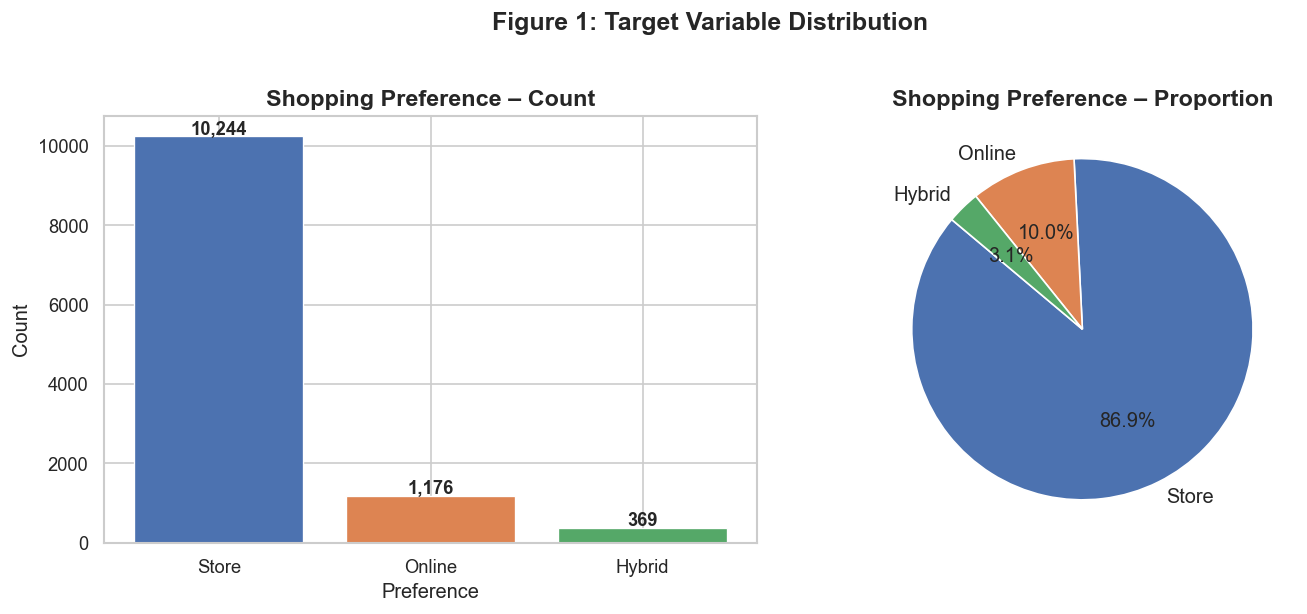


Class imbalance detected: Store >> Online >> Hybrid


In [13]:
# ─── Count and proportion of each shopping preference class ──────────────────
target_counts = df['shopping_preference'].value_counts()
target_pct    = df['shopping_preference'].value_counts(normalize=True) * 100

print('Shopping Preference Distribution:')
summary = pd.DataFrame({'Count': target_counts, 'Percentage (%)': target_pct.round(2)})
print(summary.to_string())

# ─── Visualization ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
colors = ['#4C72B0', '#DD8452', '#55A868']
axes[0].bar(target_counts.index, target_counts.values, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Shopping Preference – Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Preference')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontsize=11, fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values, labels=target_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140, textprops={'fontsize': 12})
axes[1].set_title('Shopping Preference – Proportion', fontsize=14, fontweight='bold')

plt.suptitle('Figure 1: Target Variable Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig1_target_distribution.png', bbox_inches='tight')
plt.show()
print('\nClass imbalance detected: Store >> Online >> Hybrid')

In [14]:
# ─── Calculate missing values ─────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct.round(2)})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

if missing_df.empty:
    print('No missing values found in the dataset.')
else:
    print('⚠️  Missing values detected:')
    print(missing_df.to_string())

    # Heatmap of missing values
    plt.figure(figsize=(14, 4))
    sns.heatmap(df.isnull().T, cbar=False, cmap='viridis', yticklabels=True)
    plt.title('Figure 2: Missing Values Heatmap')
    plt.tight_layout()
    plt.show()

No missing values found in the dataset.


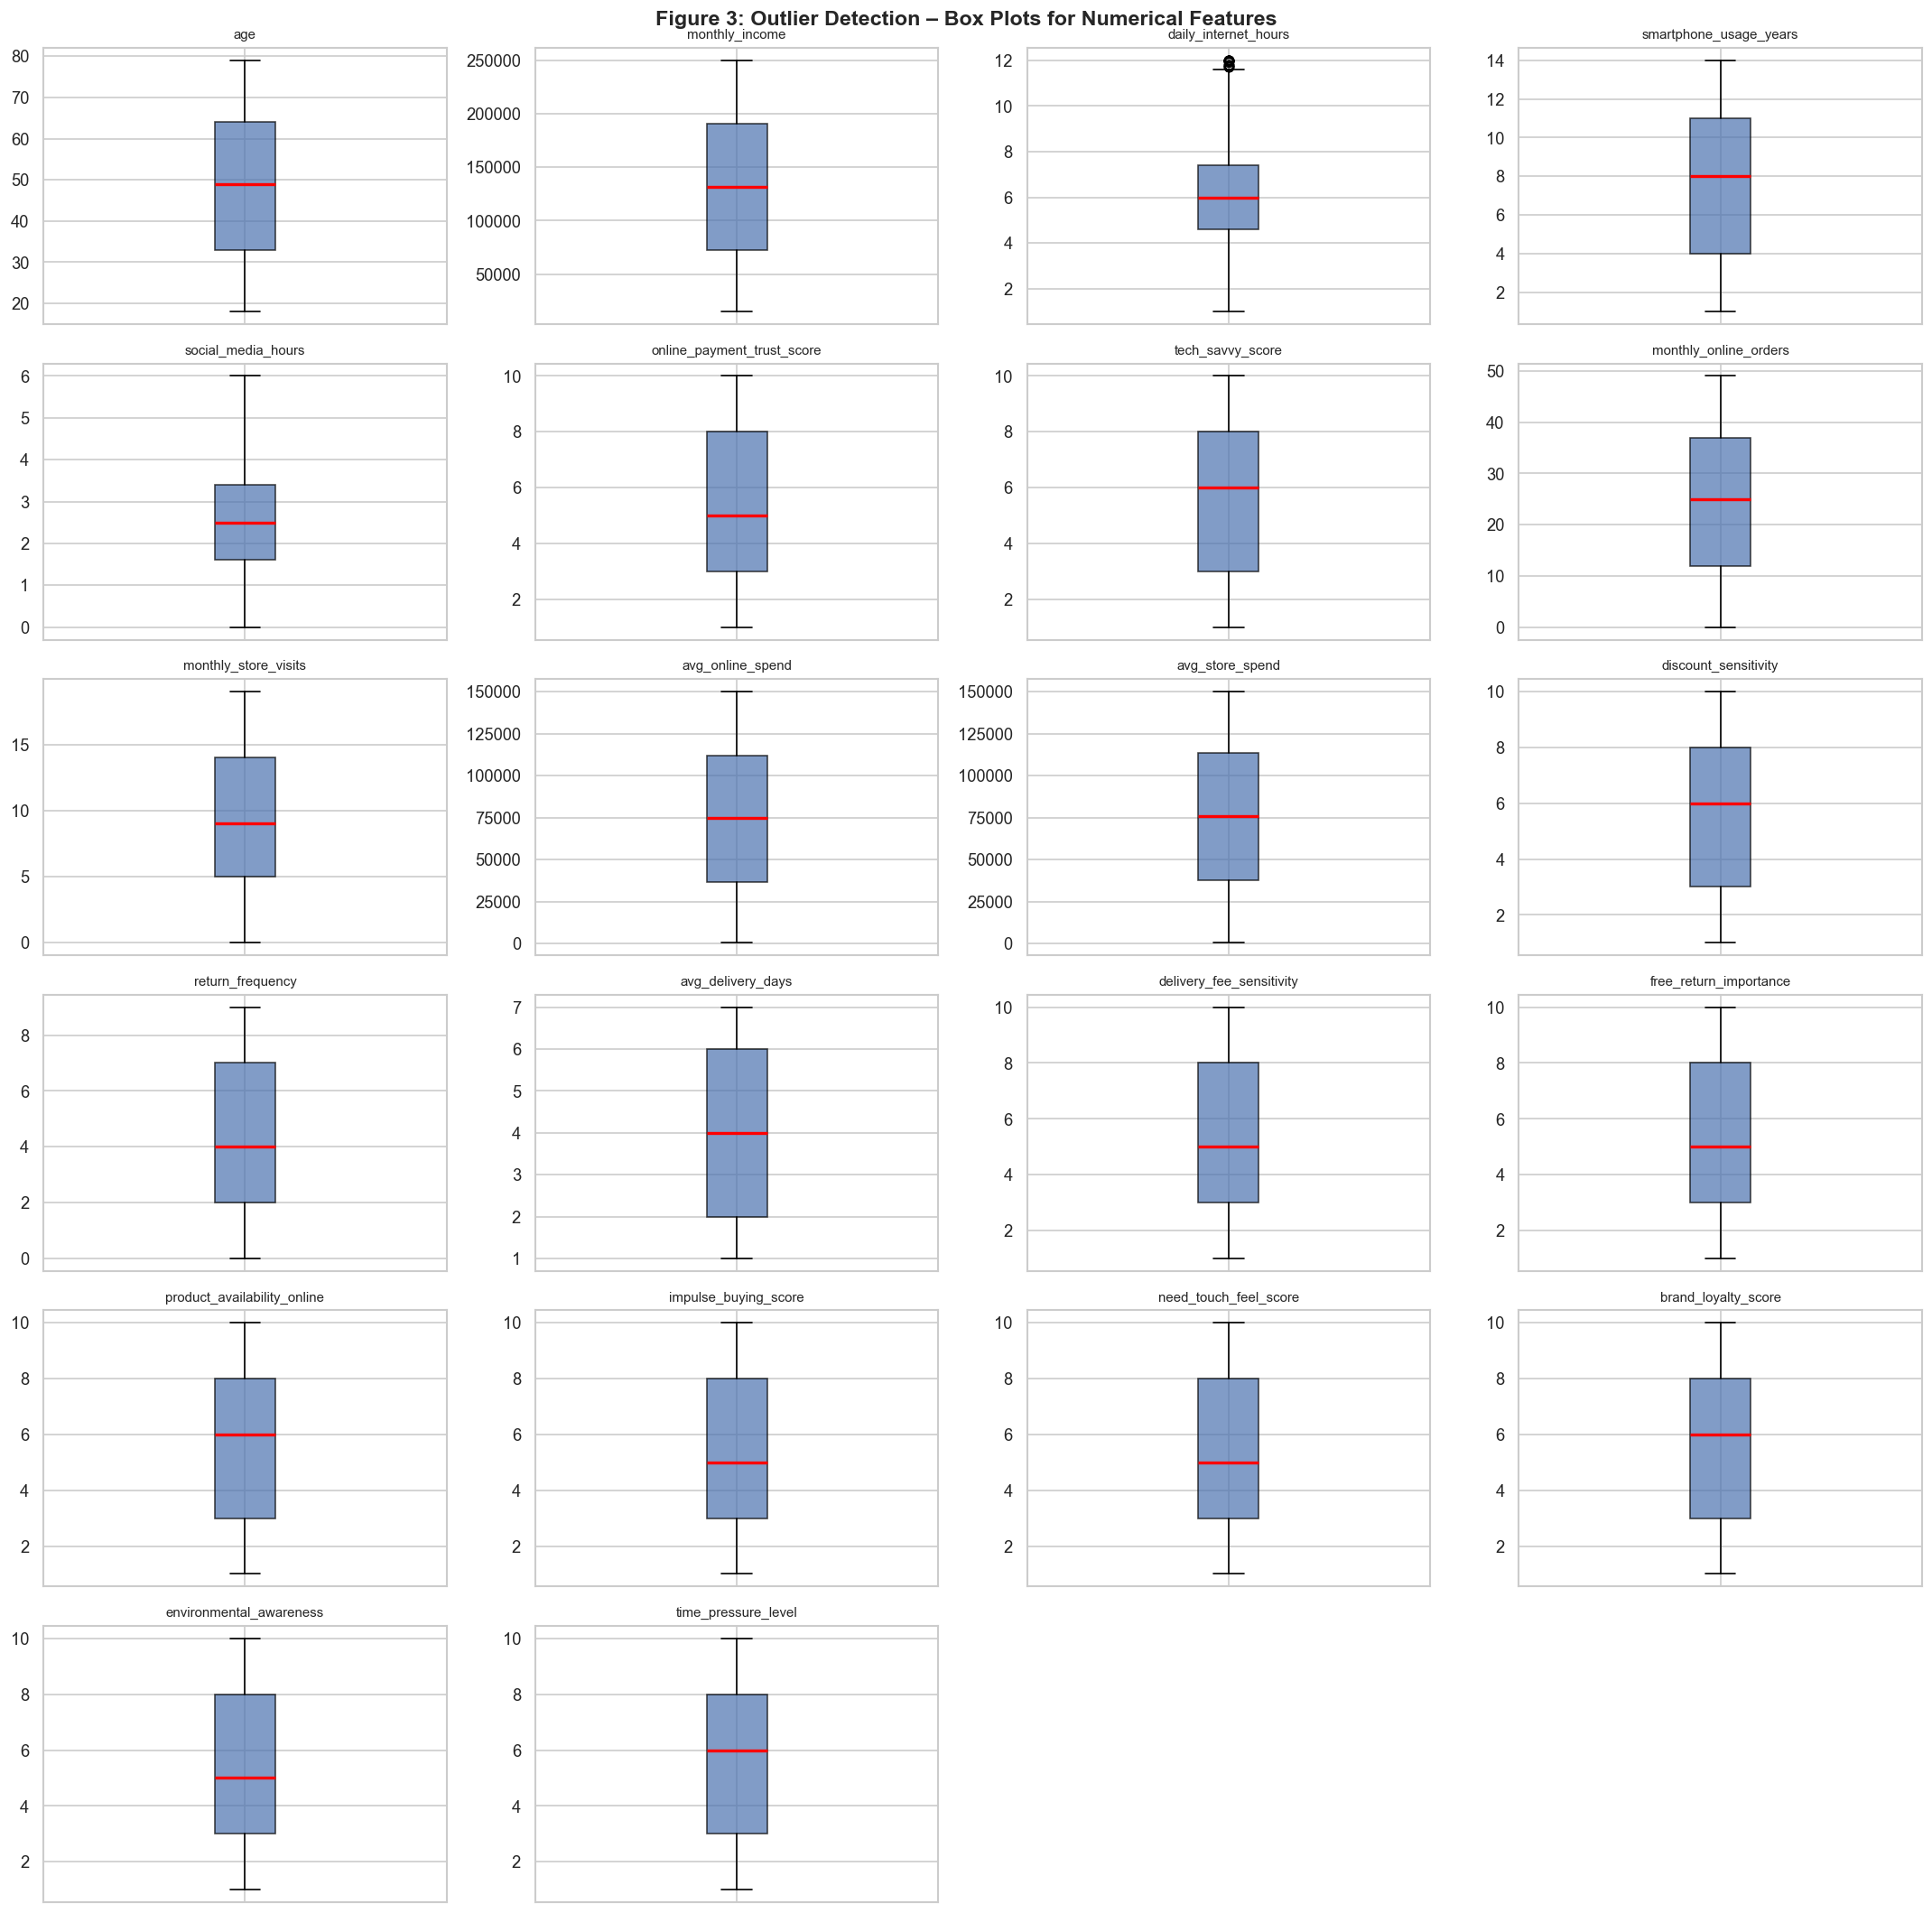


=== Outlier Count per Feature (IQR Method) ===
  daily_internet_hours: 25 outliers (0.21%)


In [15]:
# ─── Identify numerical features for outlier analysis ────────────────────────
num_features = df.select_dtypes(include=[np.number]).columns.tolist()

# Box plots for all numerical features
n_cols = 4
n_rows = (len(num_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#4C72B0', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(axis='x', which='both', bottom=False, labelbottom=False)

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Figure 3: Outlier Detection – Box Plots for Numerical Features',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_outlier_boxplots.png', bbox_inches='tight')
plt.show()

# IQR-based outlier count
print('\n=== Outlier Count per Feature (IQR Method) ===')
for col in num_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    if len(outliers) > 0:
        print(f'  {col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)')

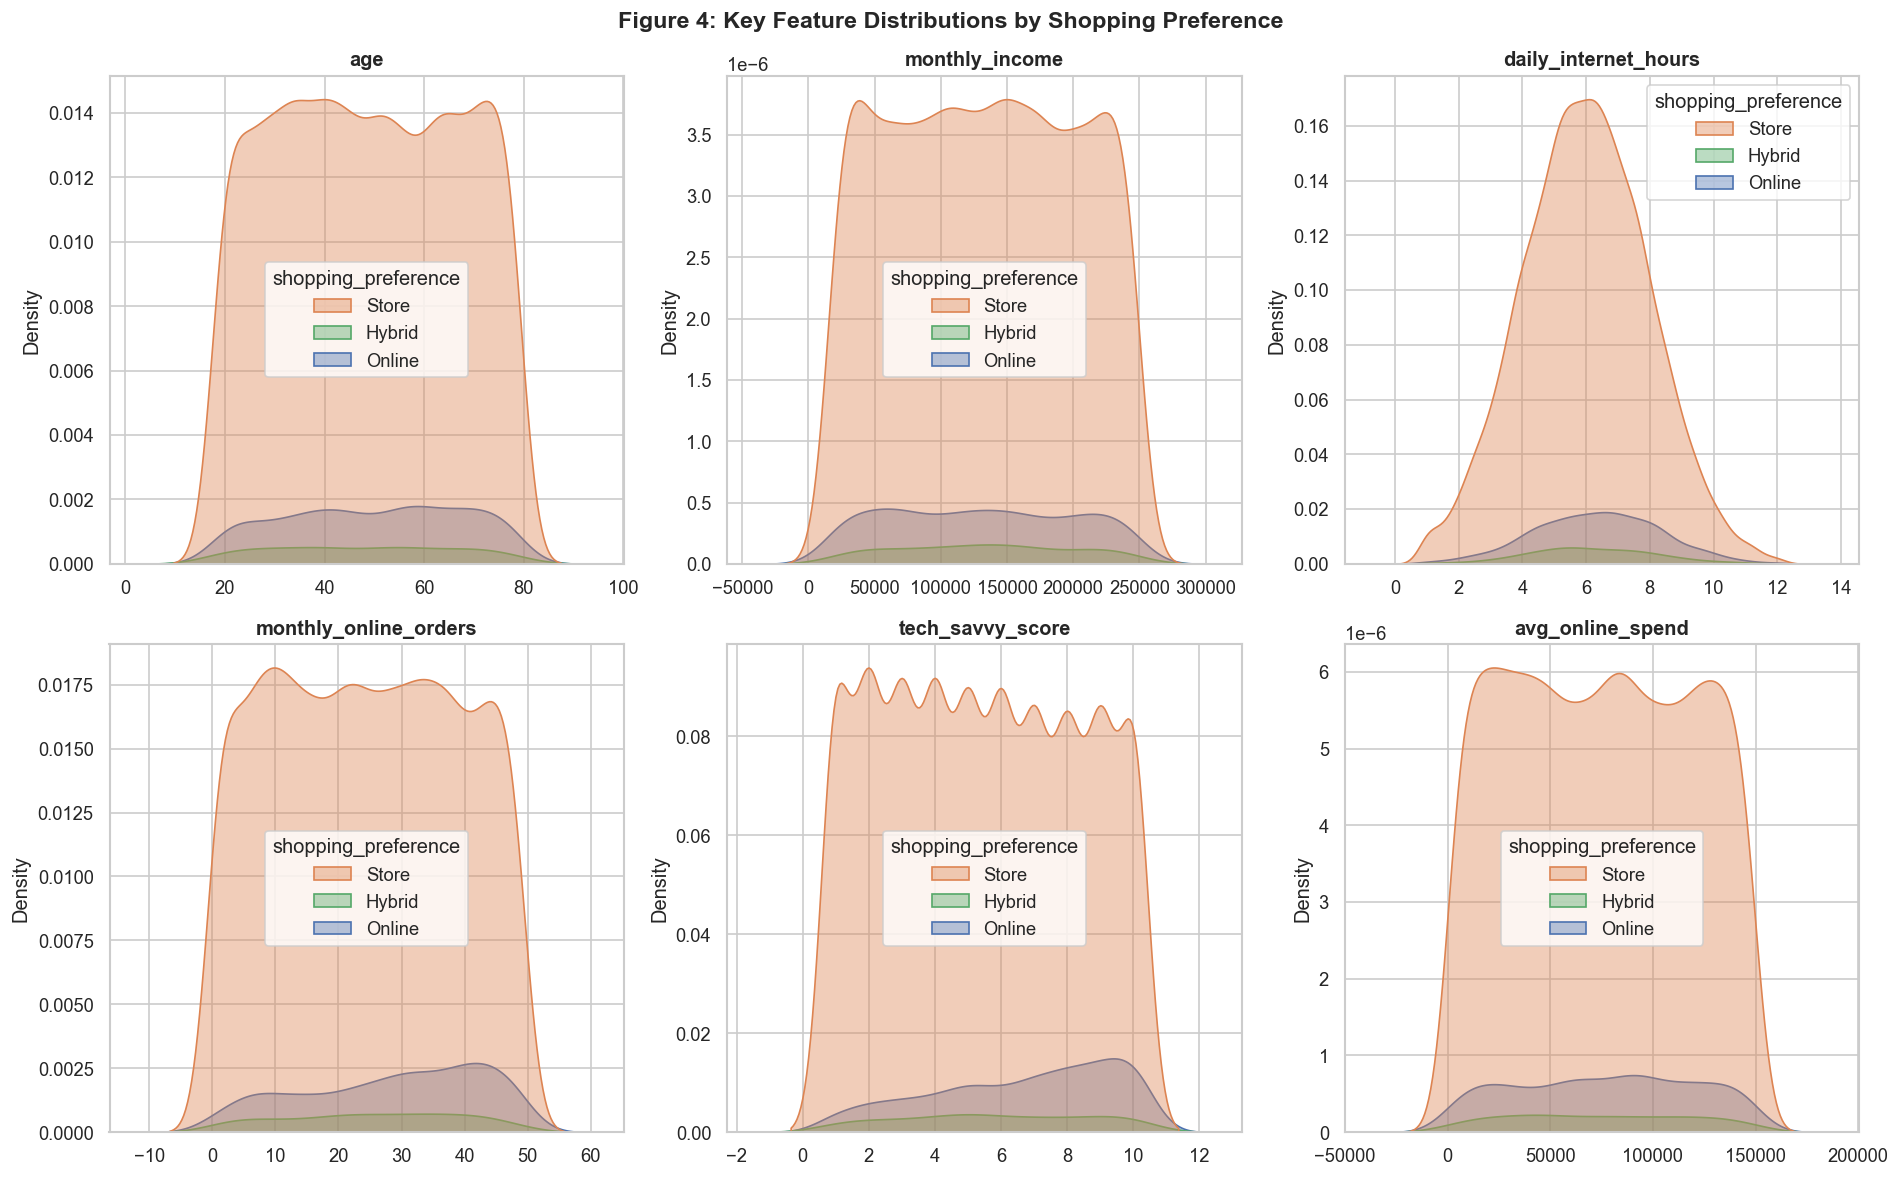

In [16]:
# ─── Key numerical features plotted by target class ──────────────────────────
key_features = ['age', 'monthly_income', 'daily_internet_hours',
                'monthly_online_orders', 'tech_savvy_score', 'avg_online_spend']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
palette = {'Online': '#4C72B0', 'Store': '#DD8452', 'Hybrid': '#55A868'}

for i, feat in enumerate(key_features):
    sns.kdeplot(data=df, x=feat, hue='shopping_preference',
                fill=True, alpha=0.4, palette=palette, ax=axes[i])
    axes[i].set_title(f'{feat}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Figure 4: Key Feature Distributions by Shopping Preference',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_feature_distributions.png', bbox_inches='tight')
plt.show()

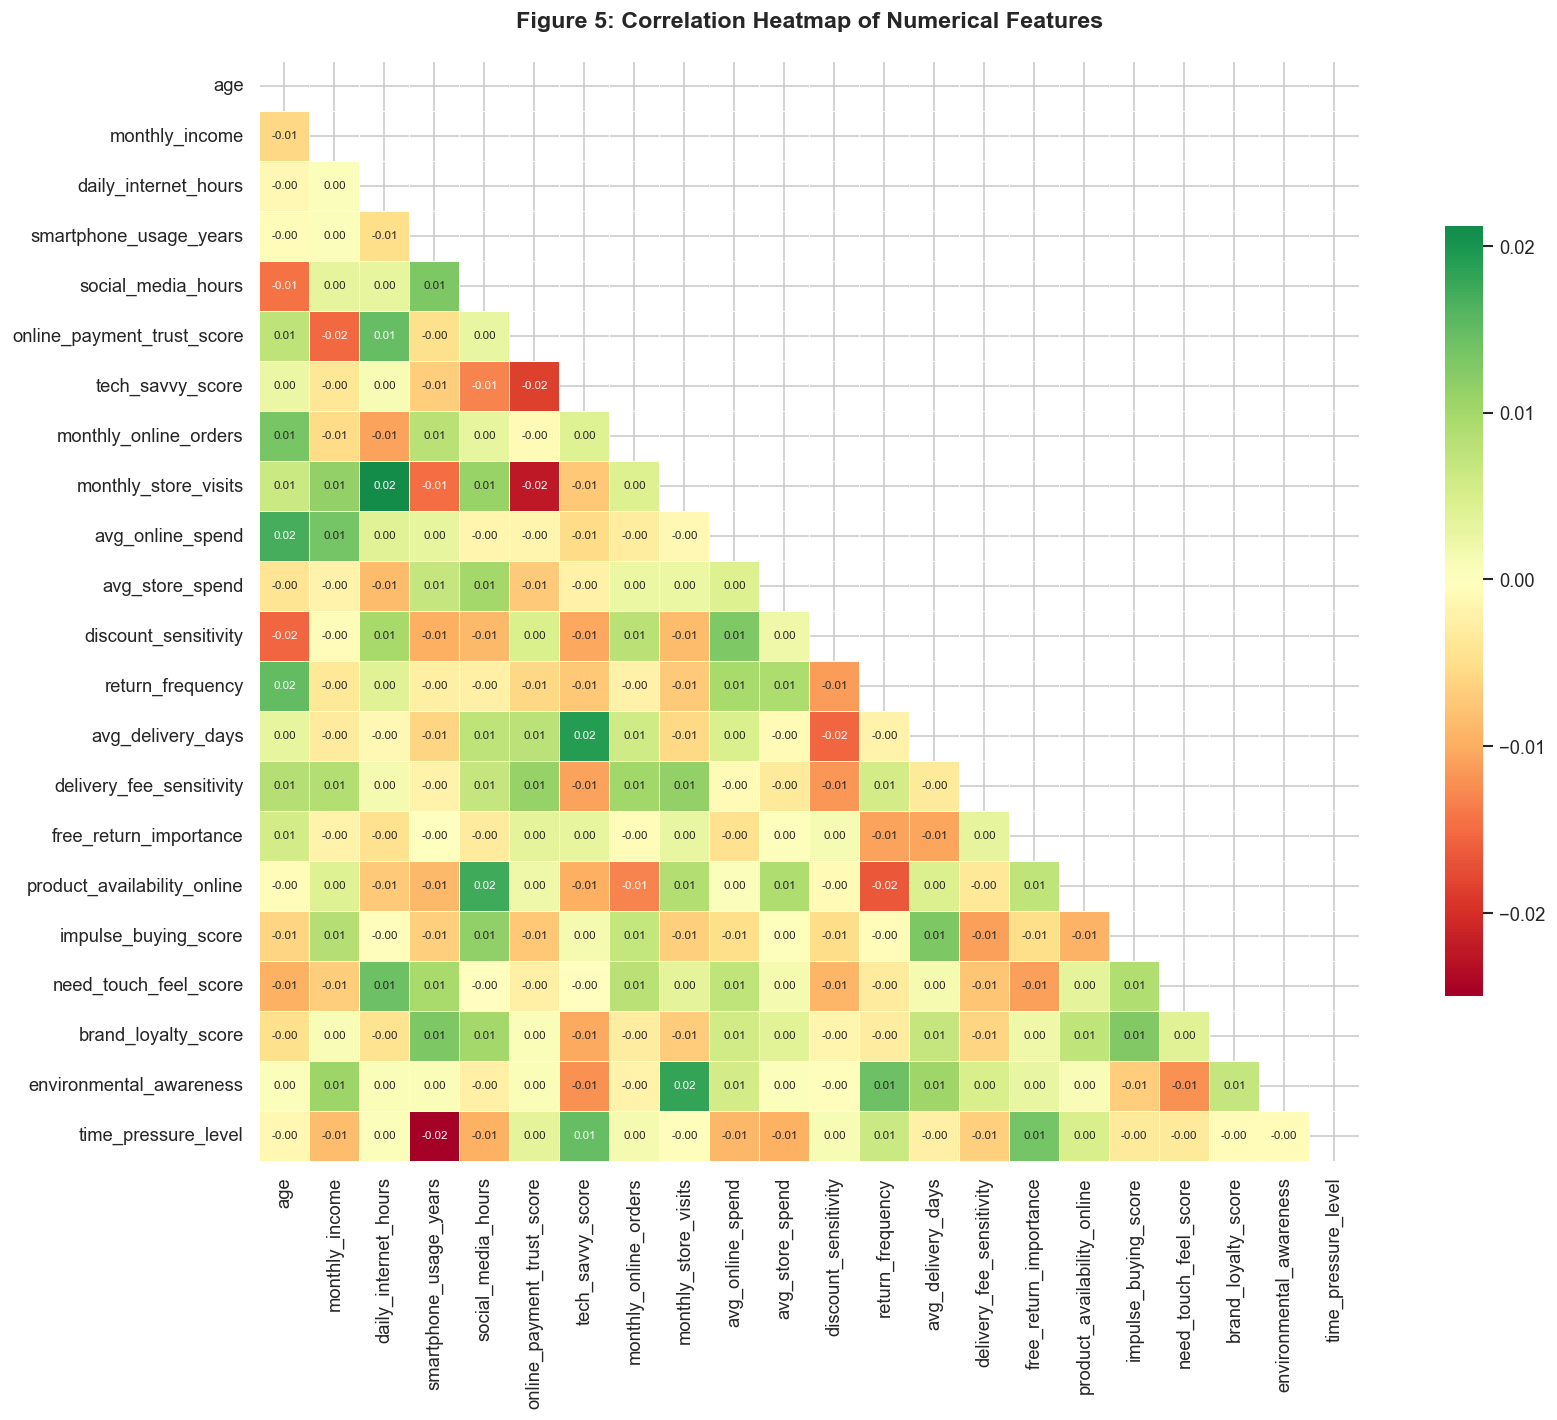

In [17]:
# ─── Correlation among numerical features ────────────────────────────────────
corr_matrix = df[num_features].corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Upper triangle mask
sns.heatmap(corr_matrix, mask=mask, cmap='RdYlGn', center=0,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            linewidths=0.5, linecolor='white',
            square=True, cbar_kws={'shrink': 0.7})
plt.title('Figure 5: Correlation Heatmap of Numerical Features',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('fig5_correlation_heatmap.png', bbox_inches='tight')
plt.show()

Categorical features: ['gender', 'city_tier']


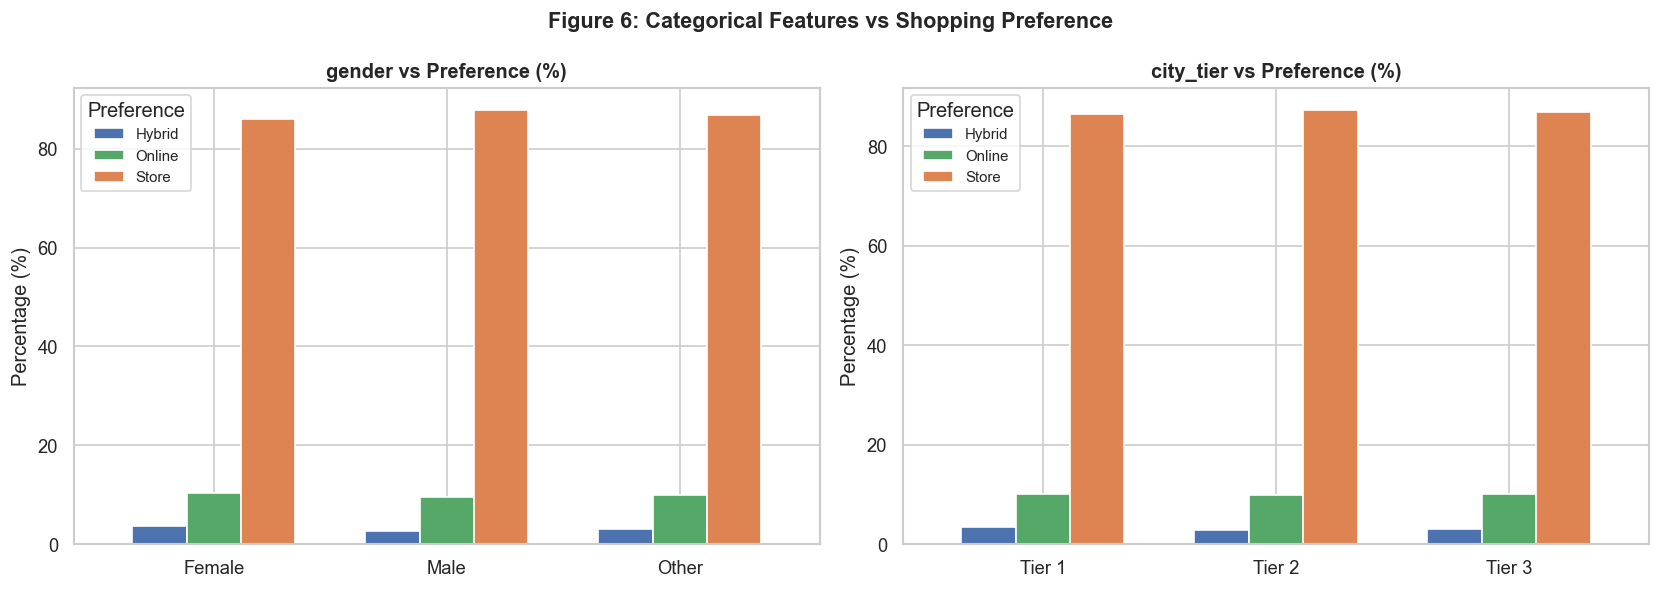

In [18]:
# ─── Count plots for categorical features by target class ────────────────────
cat_features = df.select_dtypes(include=['object']).columns.tolist()
cat_features = [c for c in cat_features if c != 'shopping_preference']

print(f'Categorical features: {cat_features}')

fig, axes = plt.subplots(1, len(cat_features), figsize=(14, 5))
if len(cat_features) == 1:
    axes = [axes]

for ax, feat in zip(axes, cat_features):
    ct = pd.crosstab(df[feat], df['shopping_preference'], normalize='index') * 100
    ct.plot(kind='bar', ax=ax, color=['#4C72B0', '#55A868', '#DD8452'],
            edgecolor='white', width=0.7)
    ax.set_title(f'{feat} vs Preference (%)', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Percentage (%)')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(title='Preference', fontsize=9)

plt.suptitle('Figure 6: Categorical Features vs Shopping Preference',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_categorical_analysis.png', bbox_inches='tight')
plt.show()

In [19]:
# ─── Step 1: Copy the raw dataframe ──────────────────────────────────────────
df_clean = df.copy()
print(f'Initial shape: {df_clean.shape}')

# ─── Step 2: Drop duplicate rows ─────────────────────────────────────────────
n_before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
n_after = len(df_clean)
print(f'Duplicates removed: {n_before - n_after} rows')

# ─── Step 3: Handle missing values ───────────────────────────────────────────
# Numerical columns: fill with median (robust to outliers)
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
for col in num_cols:
    n_missing = df_clean[col].isnull().sum()
    if n_missing > 0:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)
        print(f'  Filled {n_missing} missing values in "{col}" with median={median_val:.2f}')

# Categorical columns: fill with mode
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    n_missing = df_clean[col].isnull().sum()
    if n_missing > 0:
        mode_val = df_clean[col].mode()[0]
        df_clean[col].fillna(mode_val, inplace=True)
        print(f'  Filled {n_missing} missing values in "{col}" with mode="{mode_val}"')

# ─── Step 4: Cap outliers using IQR (Winsorizing) ────────────────────────────
# Only cap features where extreme values are data artifacts
outlier_features = ['monthly_income', 'avg_online_spend', 'avg_store_spend',
                    'monthly_online_orders', 'monthly_store_visits']

for col in outlier_features:
    if col in df_clean.columns:
        Q1  = df_clean[col].quantile(0.01)
        Q99 = df_clean[col].quantile(0.99)
        n_capped = ((df_clean[col] < Q1) | (df_clean[col] > Q99)).sum()
        df_clean[col] = df_clean[col].clip(lower=Q1, upper=Q99)
        print(f'  Capped {n_capped} outliers in "{col}" → [{Q1:.1f}, {Q99:.1f}]')

print(f'\nCleaned dataset shape: {df_clean.shape}')

Initial shape: (11789, 25)
Duplicates removed: 0 rows
  Capped 236 outliers in "monthly_income" → [17338.2, 247702.0]
  Capped 236 outliers in "avg_online_spend" → [1878.9, 148347.3]
  Capped 236 outliers in "avg_store_spend" → [1819.0, 148555.1]
  Capped 0 outliers in "monthly_online_orders" → [0.0, 49.0]
  Capped 0 outliers in "monthly_store_visits" → [0.0, 19.0]

Cleaned dataset shape: (11789, 25)


In [20]:
# ─── Define feature groups ────────────────────────────────────────────────────
TARGET          = 'shopping_preference'
CAT_FEATURES    = ['gender', 'city_tier']
NUM_FEATURES    = [c for c in df_clean.columns if c not in CAT_FEATURES + [TARGET]]

print('Categorical features to encode:', CAT_FEATURES)
print('Numerical features:', NUM_FEATURES)

# ─── Encode categorical features (Label Encoding) ────────────────────────────
# Note: For tree-based models, label encoding is acceptable.
# For linear models, one-hot encoding would be preferred.
le_dict = {}  # Store encoders for later use

df_encoded = df_clean.copy()

for col in CAT_FEATURES:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    le_dict[col] = le
    print(f'  Encoded "{col}": {dict(zip(le.classes_, le.transform(le.classes_)))}')

# ─── Encode target variable ───────────────────────────────────────────────────
le_target = LabelEncoder()
df_encoded[TARGET + '_encoded'] = le_target.fit_transform(df_encoded[TARGET])
print(f'\n  Target encoding: {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}')

df_encoded.head(3)

Categorical features to encode: ['gender', 'city_tier']
Numerical features: ['age', 'monthly_income', 'daily_internet_hours', 'smartphone_usage_years', 'social_media_hours', 'online_payment_trust_score', 'tech_savvy_score', 'monthly_online_orders', 'monthly_store_visits', 'avg_online_spend', 'avg_store_spend', 'discount_sensitivity', 'return_frequency', 'avg_delivery_days', 'delivery_fee_sensitivity', 'free_return_importance', 'product_availability_online', 'impulse_buying_score', 'need_touch_feel_score', 'brand_loyalty_score', 'environmental_awareness', 'time_pressure_level']
  Encoded "gender": {'Female': np.int64(0), 'Male': np.int64(1), 'Other': np.int64(2)}
  Encoded "city_tier": {'Tier 1': np.int64(0), 'Tier 2': np.int64(1), 'Tier 3': np.int64(2)}

  Target encoding: {'Hybrid': np.int64(0), 'Online': np.int64(1), 'Store': np.int64(2)}


,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level,gender,city_tier,shopping_preference,shopping_preference_encoded
0,56,221111.0,6.5,12,0.7,1,6,16,16,28551.0,...,7,1,3,6,5,2,2,2,Store,2
1,69,96029.0,8.2,13,2.7,6,9,14,1,124056.0,...,4,9,6,8,1,7,1,2,Hybrid,0
2,46,19055.0,6.4,4,2.1,10,8,2,0,81939.0,...,10,1,1,3,3,3,0,2,Store,2


In [21]:
# ─── Creating new derived features that may improve predictive power ────────────

# 1. Online-to-Store Spend Ratio (captures channel spend preference)
df_encoded['online_to_store_spend_ratio'] = (
    df_encoded['avg_online_spend'] /
    (df_encoded['avg_store_spend'] + 1)  # +1 to avoid division by zero
)

# 2. Digital Engagement Score (weighted composite of digital behaviors)
df_encoded['digital_engagement_score'] = (
    df_encoded['daily_internet_hours'] * 0.3 +
    df_encoded['social_media_hours']   * 0.2 +
    df_encoded['tech_savvy_score']     * 0.3 +
    df_encoded['monthly_online_orders'] * 0.2
)

# 3. Store Preference Indicator (physical shopping tendency)
df_encoded['store_preference_indicator'] = (
    df_encoded['need_touch_feel_score'] * 0.4 +
    df_encoded['monthly_store_visits']  * 0.4 +
    df_encoded['brand_loyalty_score']   * 0.2
)

# 4. Income-Spend Efficiency (income relative to spending)
df_encoded['income_spend_efficiency'] = (
    df_encoded['monthly_income'] /
    (df_encoded['avg_online_spend'] + df_encoded['avg_store_spend'] + 1)
)

# 5. Price Sensitivity Index (combined discount + delivery fee sensitivity)
df_encoded['price_sensitivity_index'] = (
    df_encoded['discount_sensitivity'] * 0.5 +
    df_encoded['delivery_fee_sensitivity'] * 0.5
)

NEW_FEATURES = [
    'online_to_store_spend_ratio',
    'digital_engagement_score',
    'store_preference_indicator',
    'income_spend_efficiency',
    'price_sensitivity_index'
]

print('Engineered features added:')
for f in NEW_FEATURES:
    print(f'  - {f}: {df_encoded[f].describe()["mean"]:.4f} (mean)')

df_encoded[NEW_FEATURES + [TARGET]].head()

Engineered features added:
  - online_to_store_spend_ratio: 2.6097 (mean)
  - digital_engagement_score: 8.9021 (mean)
  - store_preference_indicator: 7.0934 (mean)
  - income_spend_efficiency: 1.1809 (mean)
  - price_sensitivity_index: 5.4840 (mean)


,online_to_store_spend_ratio,digital_engagement_score,store_preference_indicator,income_spend_efficiency,price_sensitivity_index,shopping_preference
0,0.198143,7.09,8.8,1.280734,4.0,Store
1,4.364788,8.50,4.4,0.629789,2.5,Hybrid
2,0.639000,5.14,1.0,0.090665,6.0,Store
3,0.266623,9.06,4.8,0.311752,5.0,Store
4,3.867509,7.04,11.4,1.469144,4.5,Store


In [22]:
# ─── Select final feature set ─────────────────────────────────────────────────
ALL_FEATURES = NUM_FEATURES + CAT_FEATURES + NEW_FEATURES

X = df_encoded[ALL_FEATURES]
y = df_encoded[TARGET + '_encoded']

print(f'Feature matrix X: {X.shape}')
print(f'Target vector  y: {y.shape}')
print(f'Classes: {le_target.classes_}')

# ─── Standard Scaling (z-score normalization) ─────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=ALL_FEATURES)

print('\nStandardScaler applied.')
print(f'Mean after scaling (sample): {X_scaled_df.iloc[:, :3].mean().round(5).to_dict()}')
print(f'Std  after scaling (sample): {X_scaled_df.iloc[:, :3].std().round(5).to_dict()}')

Feature matrix X: (11789, 29)
Target vector  y: (11789,)
Classes: ['Hybrid' 'Online' 'Store']

StandardScaler applied.
Mean after scaling (sample): {'age': 0.0, 'monthly_income': 0.0, 'daily_internet_hours': 0.0}
Std  after scaling (sample): {'age': 1.00004, 'monthly_income': 1.00004, 'daily_internet_hours': 1.00004}


In [23]:
# ─── Stratified split to maintain class proportions ───────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df, y,
    test_size=0.20,      # 80% train, 20% test
    random_state=42,     # Reproducibility
    stratify=y           # Preserve class distribution
)

print('=== Train / Test Split ===')
print(f'Training set   : {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Test set       : {X_test.shape[0]:,} rows ({X_test.shape[0]/len(X)*100:.1f}%)')

# Verify class balance in splits
print('\nClass distribution (train):')
print(pd.Series(y_train).map(dict(enumerate(le_target.classes_))).value_counts())

print('\nClass distribution (test):')
print(pd.Series(y_test).map(dict(enumerate(le_target.classes_))).value_counts())

=== Train / Test Split ===
Training set   : 9,431 rows (80.0%)
Test set       : 2,358 rows (20.0%)

Class distribution (train):
shopping_preference_encoded
Store     8195
Online     941
Hybrid     295
Name: count, dtype: int64

Class distribution (test):
shopping_preference_encoded
Store     2049
Online     235
Hybrid      74
Name: count, dtype: int64


Before SMOTE (train): {2: 8195, 1: 941, 0: 295}
After  SMOTE (train): {2: 8195, 1: 8195, 0: 8195}

Training size after SMOTE: 24,585 rows


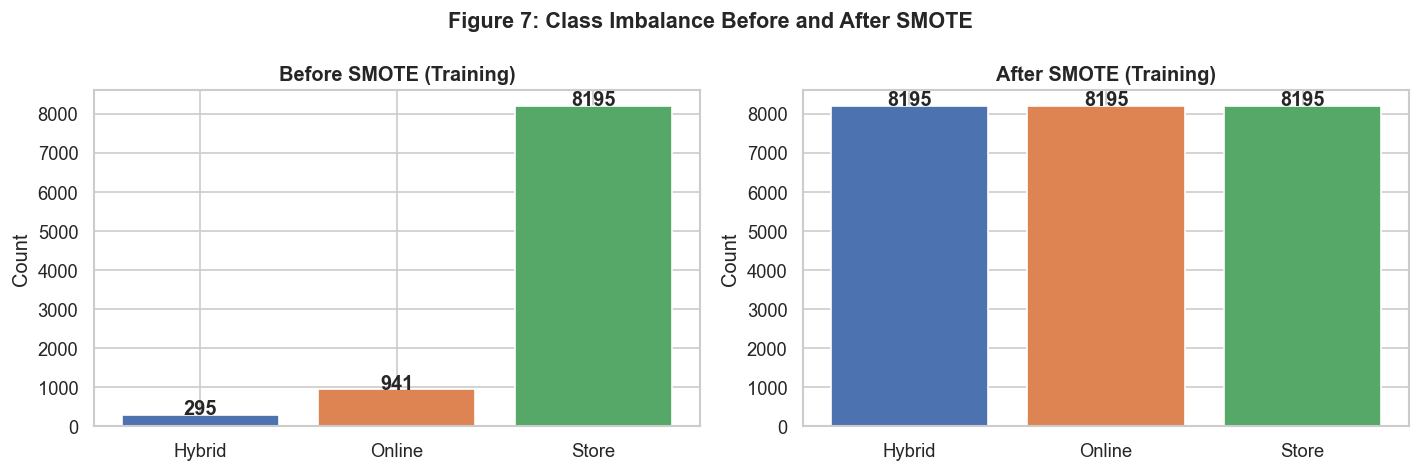

In [24]:
# ─── Apply SMOTE only on training data ───────────────────────────────────────
print('Before SMOTE (train):', pd.Series(y_train).value_counts().to_dict())

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print('After  SMOTE (train):', pd.Series(y_train_res).value_counts().to_dict())
print(f'\nTraining size after SMOTE: {len(X_train_res):,} rows')

# ─── Visualize class balance improvement ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before SMOTE
before_counts = pd.Series(y_train).value_counts().sort_index()
before_labels = [le_target.classes_[i] for i in before_counts.index]
axes[0].bar(before_labels, before_counts.values, color=colors, edgecolor='white')
axes[0].set_title('Before SMOTE (Training)', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(before_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# After SMOTE
after_counts = pd.Series(y_train_res).value_counts().sort_index()
after_labels  = [le_target.classes_[i] for i in after_counts.index]
axes[1].bar(after_labels, after_counts.values, color=colors, edgecolor='white')
axes[1].set_title('After SMOTE (Training)', fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(after_counts.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.suptitle('Figure 7: Class Imbalance Before and After SMOTE',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig7_smote_balance.png', bbox_inches='tight')
plt.show()

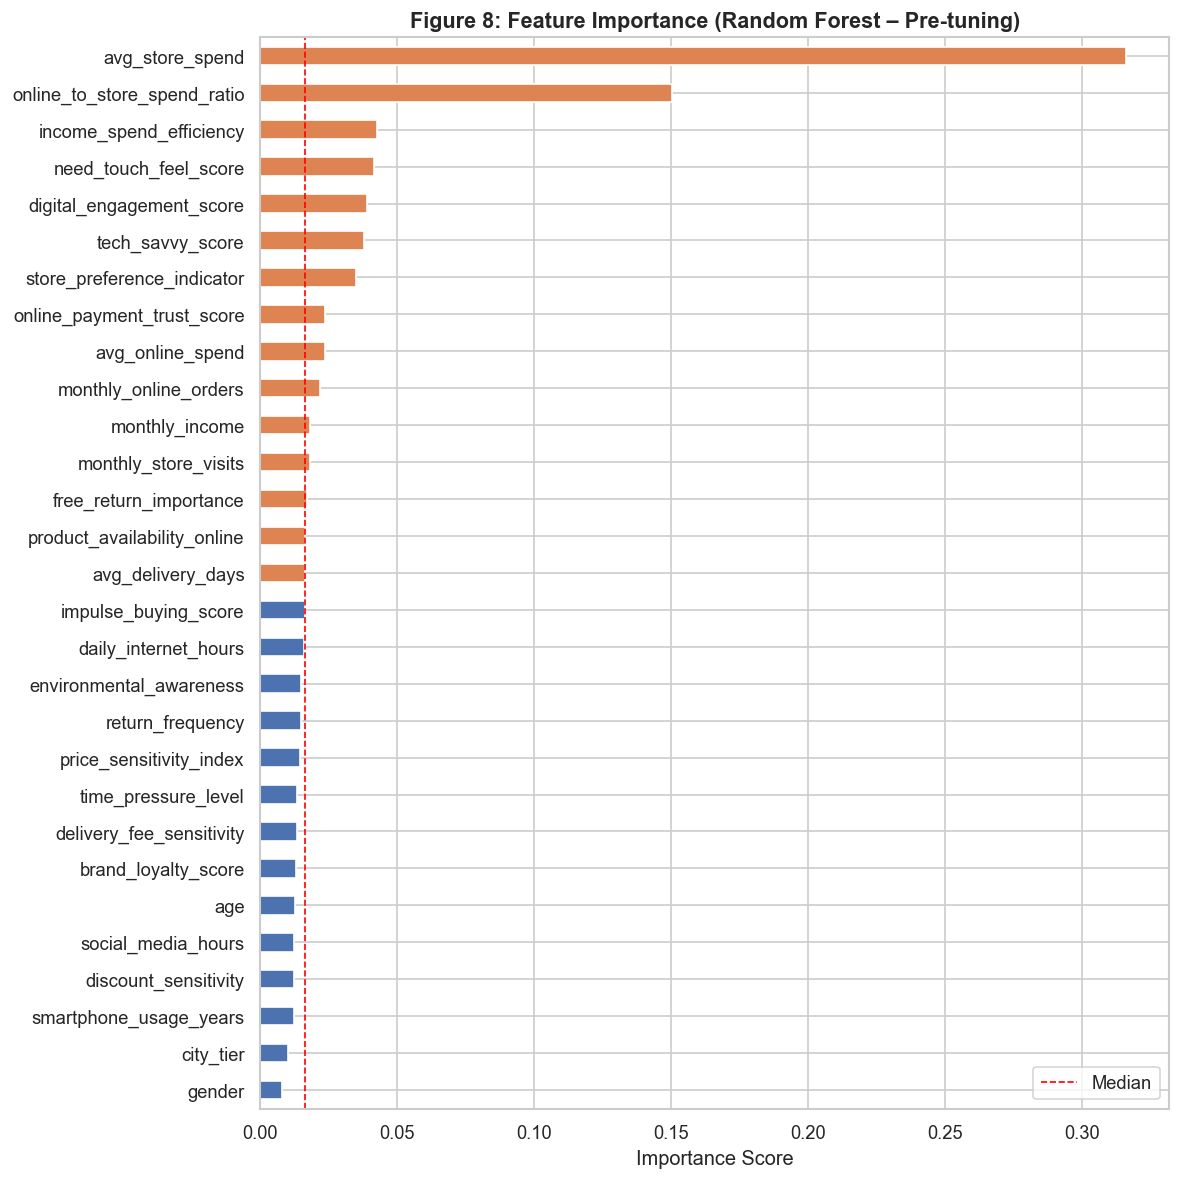


Top 10 Most Important Features:
avg_store_spend                0.316010
online_to_store_spend_ratio    0.150495
income_spend_efficiency        0.042451
need_touch_feel_score          0.041395
digital_engagement_score       0.038836
tech_savvy_score               0.037801
store_preference_indicator     0.034856
online_payment_trust_score     0.023735
avg_online_spend               0.023477
monthly_online_orders          0.021925


In [25]:
from sklearn.ensemble import RandomForestClassifier

# ─── Quick RF to estimate feature importance before full modeling ─────────────
rf_quick = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_quick.fit(X_train_res, y_train_res)

importances = pd.Series(rf_quick.feature_importances_, index=ALL_FEATURES)
importances_sorted = importances.sort_values(ascending=True)

# ─── Horizontal bar chart ────────────────────────────────────────────────────
plt.figure(figsize=(10, 10))
colors_imp = ['#4C72B0' if v < importances_sorted.median() else '#DD8452'
              for v in importances_sorted.values]
importances_sorted.plot(kind='barh', color=colors_imp, edgecolor='white')
plt.axvline(importances_sorted.median(), color='red', linestyle='--', linewidth=1, label='Median')
plt.title('Figure 8: Feature Importance (Random Forest – Pre-tuning)',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.legend()
plt.tight_layout()
plt.savefig('fig8_feature_importance.png', bbox_inches='tight')
plt.show()

print('\nTop 10 Most Important Features:')
print(importances_sorted.tail(10).sort_values(ascending=False).to_string())

In [26]:
# ─── Create output directory ──────────────────────────────────────────────────
os.makedirs('../models', exist_ok=True)

# ─── Save processed datasets (for use in model_selection.ipynb) ───────────────
X_train_res.to_csv('../models/X_train.csv', index=False)
X_test.to_csv('../models/X_test.csv', index=False)
pd.Series(y_train_res, name='target').to_csv('../models/y_train.csv', index=False)
pd.Series(y_test, name='target').to_csv('../models/y_test.csv', index=False)

# ─── Save preprocessing artifacts ─────────────────────────────────────────────
joblib.dump(scaler,    '../models/scaler.pkl')
joblib.dump(le_target, '../models/label_encoder_target.pkl')
joblib.dump(le_dict,   '../models/label_encoders_cat.pkl')

# ─── Save feature info JSON (for API / Streamlit app) ────────────────────────
feature_info = {
    'all_features': ALL_FEATURES,
    'numerical_features': NUM_FEATURES + NEW_FEATURES,
    'categorical_features': CAT_FEATURES,
    'engineered_features': NEW_FEATURES,
    'target': TARGET,
    'target_classes': le_target.classes_.tolist(),
    'categorical_values': {
        col: le_dict[col].classes_.tolist()
        for col in CAT_FEATURES
    }
}

with open('../models/feature_info.json', 'w') as f:
    json.dump(feature_info, f, indent=2)

print('All preprocessing artifacts saved to ../models/')
print('Files saved:')
for fname in os.listdir('../models'):
    print(f'  - {fname}')

All preprocessing artifacts saved to ../models/
Files saved:
  - feature_info.json
  - label_encoders_cat.pkl
  - label_encoder_target.pkl
  - scaler.pkl
  - X_test.csv
  - X_train.csv
  - y_test.csv
  - y_train.csv
